## 1. 환경 확인 및 라이브러리 설치


In [1]:
# import subprocess
# subprocess.run(['pip', 'install', 'timm', 'torchmetrics', 'torchinfo', '-q'])

import os, json, random, time
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import koreanize_matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False
from pathlib import Path
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
import timm
from torchmetrics import F1Score, ConfusionMatrix, Accuracy, AUROC
from torchmetrics.classification import MulticlassCohenKappa
from sklearn.metrics import classification_report
from torchinfo import summary

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU  : {torch.cuda.get_device_name(0)}')
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM : {total_vram:.1f} GB')
    if total_vram < 20:
        print('  VRAM이 20GB 미만입니다. BATCH_SIZE를 32로 낮추세요.')
    else:
        print('  A40 환경 확인. BATCH_SIZE=64 사용 가능.')
print('라이브러리 준비 완료')


/home/user3/.conda/envs/G-kwr/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


사용 디바이스: cuda
GPU  : NVIDIA A40
VRAM : 47.7 GB
  A40 환경 확인. BATCH_SIZE=64 사용 가능.
라이브러리 준비 완료


## 2. 경로 및 하이퍼파라미터 설정
> BASE_PATH만 서버 실제 경로에 맞게 수정하세요.

In [2]:
BASE_PATH = '/workspace/shared/data/processed/'
DATA_DIR  = Path(BASE_PATH) / 'data_processed_v6'
RUN_ID    = datetime.now().strftime('%m%d_%H%M')  # 예: 0423_1530
CKPT_DIR  = Path(f'/workspace/user3/out/checkpoints_efficientnetV2-M_{RUN_ID}')
PLOT_DIR  = Path(f'/workspace/user3/out/plots_efficientnetV2-M_{RUN_ID}')
CKPT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

CLASSES     = ['anger', 'happy', 'panic', 'sadness']
NUM_CLASSES = len(CLASSES)
IMG_SIZE    = 224

BATCH_SIZE    = 64    # VRAM 부족 시 32로 낮추세요
EPOCHS        = 50
LR            = 1e-4  # EfficientNet 계열 권장 LR
WEIGHT_DECAY  = 1e-2
WARMUP_EPOCHS = 5
PATIENCE      = 7
GRAD_CLIP     = 1.0
LABEL_SMOOTH  = 0.1

USE_AMP     = True
AMP_DTYPE   = torch.bfloat16
USE_COMPILE = True

scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

for name, path in [('DATA_DIR', DATA_DIR), ('CKPT_DIR', CKPT_DIR)]:
    status = 'OK' if path.exists() else 'NOT FOUND'
    print(f'[{status}] {name}: {path}')
    if status == 'NOT FOUND':
        raise FileNotFoundError(f'{path} 경로를 확인하세요.')

cw_path = DATA_DIR / 'class_weights.json'
if not cw_path.exists():
    raise FileNotFoundError('class_weights.json 없음. 전처리를 먼저 실행하세요.')
with open(cw_path) as f:
    cw_dict = json.load(f)
CLASS_WEIGHTS = torch.tensor([cw_dict[c] for c in CLASSES], dtype=torch.float).to(DEVICE)

print('\n======== EfficientNetV2-M 학습 설정 완료 ==========')
print(f'배치 사이즈    : {BATCH_SIZE}')
print(f'에폭           : {EPOCHS}  (Early Stopping patience={PATIENCE})')
print(f'학습률         : {LR}  (Warmup {WARMUP_EPOCHS} epoch -> Cosine)')
print(f'Mixed Precision: {USE_AMP} ({AMP_DTYPE})')
print(f'torch.compile  : {USE_COMPILE}')
print(f'Class Weights  : {cw_dict}')


[OK] DATA_DIR: /workspace/shared/data/processed/data_processed_v6
[OK] CKPT_DIR: /workspace/user3/out/checkpoints_efficientnetV2-M_0423_0640

======== EfficientNetV2-M 학습 설정 완료 ==========
배치 사이즈    : 64
에폭           : 50  (Early Stopping patience=7)
학습률         : 0.0001  (Warmup 5 epoch -> Cosine)
Mixed Precision: True (torch.bfloat16)
torch.compile  : True
Class Weights  : {'anger': 0.9973, 'happy': 1.0097, 'panic': 0.9957, 'sadness': 0.9973}


## 3. DataLoader 구성

In [3]:
# ─────────────────────────────────────────────
# 이미지 정규화 (Normalization)
# EfficientnetV2-M는 ImageNet 데이터로 사전학습되었으므로
# 동일한 평균(MEAN)과 표준편차(STD)로 정규화해야 사전학습 효과를 유지할 수 있음
# ─────────────────────────────────────────────
MEAN = [0.485, 0.456, 0.406]  # ImageNet RGB 채널별 평균
STD  = [0.229, 0.224, 0.225]  # ImageNet RGB 채널별 표준편차

# ─────────────────────────────────────────────
# 온라인 증강 (Online Augmentation)
# 전처리 단계에서 증강을 저장하지 않고, DataLoader에서 매 에폭마다 랜덤 적용
# 장점: 에폭마다 다른 변형 이미지를 보게 되어 데이터 다양성 극대화
#       → 같은 이미지 수로 더 많은 패턴을 학습할 수 있음
# ─────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),           # 좌우 반전: 얼굴 방향 다양성
    transforms.RandomRotation(degrees=15),             # 회전 (+-15도): 고개 기울기 대응
    transforms.ColorJitter(brightness=0.3,             # 밝기 변화: 조명 다양성
                           contrast=0.3,               # 대비 변화
                           saturation=0.2),            # 채도 변화: 피부톤 다양성
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

# val/test는 증강 없이 Resize + Normalize만 (평가 일관성 유지)
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

# ImageFolder: 폴더 구조(train/anger, train/happy, ...)를 자동으로 클래스로 인식
train_dataset = datasets.ImageFolder(DATA_DIR / 'train', transform=train_transform)
val_dataset   = datasets.ImageFolder(DATA_DIR / 'val',   transform=val_transform)
test_dataset  = datasets.ImageFolder(DATA_DIR / 'test',  transform=val_transform)

# ─────────────────────────────────────────────
# DataLoader 설정
# shuffle=True  : train은 매 에폭마다 순서를 섞어 과적합 방지
# shuffle=False : val/test는 평가 일관성을 위해 순서 유지
# num_workers=8 : CPU 8개 코어로 데이터 병렬 로딩 (서버 환경 최적화)
# pin_memory=True : CPU->GPU 데이터 전송 속도 향상
# persistent_workers=True : 에폭 간 워커 프로세스 유지 (재생성 오버헤드 감소)
# ─────────────────────────────────────────────
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True, persistent_workers=True)

print('====== 데이터셋 로드 완료 =======')
print(f'Train: {len(train_dataset)}장  |  Val: {len(val_dataset)}장  |  Test: {len(test_dataset)}장')
print(f'클래스 인덱스: {train_dataset.class_to_idx}')
print('  Train transform: Resize + Flip + Rotate + ColorJitter + Normalize (온라인 증강)')
print('  Val/Test transform: Resize + Normalize only')


====== 데이터셋 로드 완료 =======
Train: 4875장  |  Val: 1398장  |  Test: 698장
클래스 인덱스: {'anger': 0, 'happy': 1, 'panic': 2, 'sadness': 3}
  Train transform: Resize + Flip + Rotate + ColorJitter + Normalize (온라인 증강)
  Val/Test transform: Resize + Normalize only


## 4. EfficientNetV2-M 모델 정의


In [4]:
# 앙상블이나 실험 반복할 때 활용하기 위해 수정을 편하게 하기 위해서...

def build_efficientnet_model(num_classes=4):
    """
    EfficientNetV2-M 모델 생성 함수

    - EfficientNetV2-M:
        MBConv + Fused-MBConv 블록 조합으로 구성
        V2는 V1 대비 학습 속도 3~4배 향상
        파라미터 수 ~54M으로 Swin(86M)보다 가볍고 빠름
    - pretrained=True: ImageNet 사전학습 가중치 사용
    - num_classes: 마지막 분류 레이어를 4개 클래스로 교체
    """
    model = timm.create_model(
        'tf_efficientnetv2_m',
        pretrained=True,
        num_classes=num_classes
    )
    return model


efficientnet_model  = build_efficientnet_model(num_classes=NUM_CLASSES).to(DEVICE)
efficientnet_params = sum(p.numel() for p in efficientnet_model.parameters() if p.requires_grad)
print(f'EfficientNetV2-M 파라미터 수: {efficientnet_params:,}')

if torch.cuda.is_available():
    dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):
        _ = efficientnet_model(dummy)
    print(f'VRAM 사전 점검 완료')
    del dummy
    torch.cuda.empty_cache()


EfficientNetV2-M 파라미터 수: 52,863,480


/tmp/ipykernel_2054782/1167533626.py:28: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP, dtype=AMP_DTYPE):


VRAM 사전 점검 완료


## 5. 모델 구조 확인

In [5]:
# torch.compile 적용 시 모델이 래핑(wrapping)되므로
# 원본 모델(_orig_mod)을 꺼내야 summary가 정상 작동함
raw_model = efficientnet_model._orig_mod if hasattr(efficientnet_model, '_orig_mod') else efficientnet_model

# 모델 구조 출력 (레이어명, 입출력 크기, 파라미터 수)
# depth=3: 3단계까지 세부 구조 표시
summary(
    raw_model,
    input_size=(1, 3, IMG_SIZE, IMG_SIZE),
    col_names=['input_size', 'output_size', 'num_params'],
    depth=3
)

# 부가 설명을 하자면 학습할 때는 래퍼(efficientnet_model), 구조 출력할 때만 원본(_orig_mod)을 꺼내는 방식

Layer (type:depth-idx)                        Input Shape               Output Shape              Param #
EfficientNet                                  [1, 3, 224, 224]          [1, 4]                    --
├─Conv2dSame: 1-1                             [1, 3, 224, 224]          [1, 24, 112, 112]         648
├─BatchNormAct2d: 1-2                         [1, 24, 112, 112]         [1, 24, 112, 112]         48
│    └─Identity: 2-1                          [1, 24, 112, 112]         [1, 24, 112, 112]         --
│    └─SiLU: 2-2                              [1, 24, 112, 112]         [1, 24, 112, 112]         --
├─Sequential: 1-3                             [1, 24, 112, 112]         [1, 512, 7, 7]            --
│    └─Sequential: 2-3                        [1, 24, 112, 112]         [1, 24, 112, 112]         --
│    │    └─ConvBnAct: 3-1                    [1, 24, 112, 112]         [1, 24, 112, 112]         5,232
│    │    └─ConvBnAct: 3-2                    [1, 24, 112, 112]         [1, 24, 11

## 6. 학습 함수 정의

In [6]:
def train_one_epoch(model, loader, criterion, optimizer):
    """
    1 에폭 학습 함수
    - Mixed Precision(BF16)으로 연산해 속도 향상
    - Gradient Clipping으로 그래디언트 폭발 방지
    - 반환값: (에폭 평균 손실, 에폭 정확도)
    """
    model.train()  # 드롭아웃, 배치정규화 등을 학습 모드로 전환
    total_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(loader, desc='train', leave=False)  # 진행률 표시
    for imgs, labels in pbar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)  # GPU로 이동
        optimizer.zero_grad()  # 이전 배치의 그래디언트 초기화

        # autocast: 지정한 dtype(BF16)으로 자동 형변환하여 연산
        # -> FP32 대비 메모리 절약 + 속도 향상
        with torch.amp.autocast('cuda', enabled=USE_AMP, dtype=AMP_DTYPE):
            outputs = model(imgs)          # 순전파
            loss    = criterion(outputs, labels)  # 손실 계산

        # scaler.scale: BF16 환경에서 그래디언트 스케일 조정 후 역전파
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)  # 클리핑 전에 스케일 제거
        # Gradient Clipping: 그래디언트 norm이 GRAD_CLIP을 넘으면 잘라냄
        # EfficientnetV2-M처럼 깊은 모델에서 그래디언트 폭발 방지에 효과적
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        scaler.step(optimizer)  # 파라미터 업데이트
        scaler.update()         # 다음 배치를 위해 scaler 상태 갱신

        total_loss += loss.item() * imgs.size(0)  # 배치 크기 가중 합산
        correct    += (outputs.argmax(1) == labels).sum().item()  # 맞춘 개수
        total      += imgs.size(0)
        pbar.set_postfix(loss=f'{total_loss/total:.4f}', acc=f'{correct/total*100:.1f}%')

    return total_loss / total, correct / total


@torch.no_grad()  # 평가 시에는 그래디언트 계산 불필요 -> 메모리 절약
def evaluate(model, loader, criterion, desc='val'):
    """
    검증/테스트 평가 함수
    - @torch.no_grad(): 역전파 계산 없이 순전파만 수행 -> 메모리/속도 효율
    - 반환값: (에폭 평균 손실, 에폭 정확도)
    """
    model.eval()  # 드롭아웃 비활성화, 배치정규화 추론 모드 전환
    total_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(loader, desc=desc, leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.amp.autocast('cuda', enabled=USE_AMP, dtype=AMP_DTYPE):
            outputs = model(imgs)
            loss    = criterion(outputs, labels)

        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
        pbar.set_postfix(loss=f'{total_loss/total:.4f}', acc=f'{correct/total*100:.1f}%')

    return total_loss / total, correct / total


def train_model(model, model_name):
    """
    전체 학습 루프 함수

    [손실 함수]
    - CrossEntropyLoss: 다중 클래스 분류의 표준 손실 함수
    - weight=CLASS_WEIGHTS: 클래스 불균형 보정 (데이터 수가 적은 클래스에 높은 가중치)
    - label_smoothing=0.1: 정답 라벨을 0.9로, 나머지에 0.1을 분배
      -> 모델이 과도하게 확신하는 것을 방지, 일반화 성능 향상

    [옵티마이저]
    - AdamW: Adam + Weight Decay 분리 적용 -> 사전학습 모델 Fine-tuning에 적합

    [학습률 스케줄러]
    - LinearLR (Warmup): 첫 WARMUP_EPOCHS 동안 학습률을 0.1*LR -> LR로 선형 증가
      -> 사전학습 가중치가 초반에 급격히 변하는 것 방지
    - CosineAnnealingLR: Warmup 이후 학습률을 코사인 곡선으로 감소
      -> 학습 후반부에 세밀한 파라미터 조정 가능

    [Early Stopping]
    - 검증 손실이 PATIENCE 에폭 동안 개선되지 않으면 학습 조기 종료
    - 과적합 방지 및 불필요한 학습 시간 낭비 방지

    반환값: (학습 기록 딕셔너리, 최적 모델 저장 경로)
    """
    criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS, label_smoothing=LABEL_SMOOTH)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    # 스케줄러 구성: Warmup -> Cosine 순서로 적용
    warmup    = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS)
    cosine    = CosineAnnealingLR(optimizer, T_max=EPOCHS - WARMUP_EPOCHS)
    scheduler = SequentialLR(optimizer, schedulers=[warmup, cosine], milestones=[WARMUP_EPOCHS])

    # 학습 기록 저장용 딕셔너리 (나중에 학습 곡선 시각화에 사용)
    history          = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
    best_val_loss    = float('inf')  # 최적 검증 손실 초기값
    patience_counter = 0             # Early Stopping 카운터
    ckpt_path        = CKPT_DIR / f'{model_name}_best.pth'  # 최적 모델 저장 경로
    start_time       = time.time()

    print(f'\n[{model_name}] 학습 시작 / 최대 {EPOCHS} 에폭')
    print('=' * 70)

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss,   val_acc   = evaluate(model, val_loader, criterion)
        scheduler.step()  # 스케줄러 1 스텝 진행

        # 학습 기록 저장
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # 검증 손실이 개선되면 모델 저장, 아니면 patience 카운터 증가
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            patience_counter = 0
            # torch.compile 적용 시 _orig_mod로 원본 모델 state_dict 저장
            state = model._orig_mod.state_dict() if hasattr(model, '_orig_mod') else model.state_dict()
            torch.save(state, str(ckpt_path))
            saved_mark = ' <- Best 저장'
        else:
            patience_counter += 1
            saved_mark = f' (patience {patience_counter}/{PATIENCE})'

        lr_now = optimizer.param_groups[0]['lr']  # 현재 학습률 확인
        print(f'Epoch [{epoch:3d}/{EPOCHS}]  '
              f'Train Loss: {train_loss:.4f}  Acc: {train_acc*100:.2f}%  |  '
              f'Val Loss: {val_loss:.4f}  Acc: {val_acc*100:.2f}%  '
              f'LR: {lr_now:.2e}{saved_mark}')

        # Early Stopping: patience 초과 시 학습 종료
        if patience_counter >= PATIENCE:
            print(f'\nEarly Stopping @ Epoch {epoch}')
            break

    elapsed = time.time() - start_time
    print(f'\n총 학습 시간: {elapsed/60:.1f}분')
    print(f'Best 모델 저장 위치: {ckpt_path}')
    return history, str(ckpt_path)


print('학습 함수 정의 완료')

학습 함수 정의 완료


## 7. 학습 실행

In [7]:
# 학습 실행 -> 학습 기록(EfficientnetV2-M_history)과 최적 모델 경로(EfficientnetV2-M_ckpt) 반환
efficientnet_history, efficientnet_ckpt = train_model(efficientnet_model, 'efficientnet')


[efficientnet] 학습 시작 / 최대 50 에폭


Epoch [  1/50]  Train Loss: 6.6809  Acc: 35.14%  |  Val Loss: 4.9563  Acc: 42.56%  LR: 2.80e-05 <- Best 저장


Epoch [  2/50]  Train Loss: 2.9427  Acc: 58.61%  |  Val Loss: 2.4565  Acc: 60.52%  LR: 4.60e-05 <- Best 저장


Epoch [  3/50]  Train Loss: 1.2899  Acc: 68.33%  |  Val Loss: 1.0064  Acc: 72.60%  LR: 6.40e-05 <- Best 저장


Epoch [  4/50]  Train Loss: 0.7620  Acc: 80.59%  |  Val Loss: 0.8051  Acc: 77.68%  LR: 8.20e-05 <- Best 저장


...

Epoch [ 28/50]  Train Loss: 0.3536  Acc: 99.92%  |  Val Loss: 0.6154  Acc: 87.77%  LR: 4.83e-05 (patience 3/7)


Epoch [ 29/50]  Train Loss: 0.3521  Acc: 99.98%  |  Val Loss: 0.6039  Acc: 88.13%  LR: 4.48e-05 (patience 4/7)


Epoch [ 30/50]  Train Loss: 0.3528  Acc: 99.92%  |  Val Loss: 0.6105  Acc: 88.13%  LR: 4.13e-05 (patience 5/7)


Epoch [ 31/50]  Train Loss: 0.3531  Acc: 99.92%  |  Val Loss: 0.6043  Acc: 88.48%  LR: 3.79e-05 (patience 6/7)


Epoch [ 32/50]  Train Loss: 0.3516  Acc: 99.96%  |  Val Loss: 0.5943  Acc: 88.91%  LR: 3.45e-05 (patience 7/7)

Early Stopping @ Epoch 32

총 학습 시간: 11.8분
Best 모델 저장 위치: /workspace/user3/out/checkpoints_efficientnetV2-M_0423_0640/efficientnet_best.pth


## 8. 학습 곡선 시각화

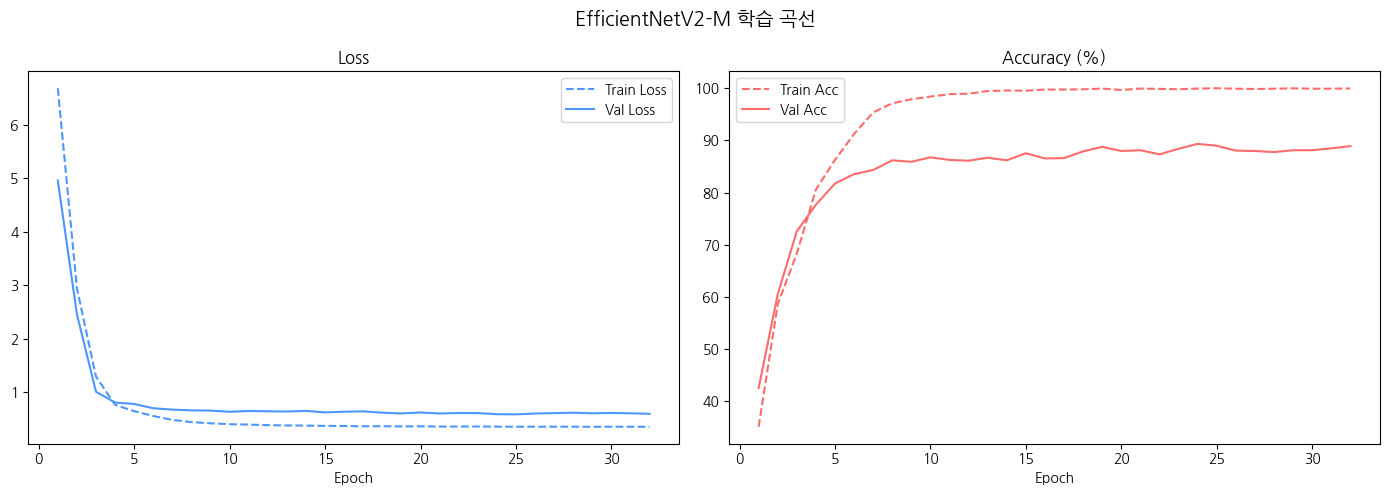

학습 곡선 저장 완료


In [8]:
def plot_history(history, model_name):
    """
    학습 곡선 시각화 함수
    - 왼쪽: Train/Val Loss 변화 (낮을수록 좋음)
    - 오른쪽: Train/Val Accuracy 변화 (높을수록 좋음)
    - Train과 Val 곡선의 격차가 크면 과적합 의심
    """
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} 학습 곡선', fontsize=14)

    # Loss 그래프: 점선=Train, 실선=Val
    axes[0].plot(epochs, history['train_loss'], label='Train Loss', color='#4D96FF', linestyle='--')
    axes[0].plot(epochs, history['val_loss'],   label='Val Loss',   color='#4D96FF')
    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

    # Accuracy 그래프: 점선=Train, 실선=Val
    axes[1].plot(epochs, [a*100 for a in history['train_acc']], label='Train Acc', color='#FF6B6B', linestyle='--')
    axes[1].plot(epochs, [a*100 for a in history['val_acc']],   label='Val Acc',   color='#FF6B6B')
    axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch'); axes[1].legend()

    plt.tight_layout()
    plt.savefig(str(CKPT_DIR / 'efficientnet_learning_curve.png'), dpi=150)  # PNG 저장
    plt.show()
    print('학습 곡선 저장 완료')


plot_history(efficientnet_history, 'EfficientNetV2-M')

## 9. 최종 평가 (Test Set)

In [9]:
@torch.no_grad()
def full_evaluate(model, ckpt_path, model_name):
    """
    테스트셋 최종 평가 함수
    - 학습 중 저장한 Best 모델 가중치를 불러와 테스트셋으로 평가
    - Accuracy, Top-2 Acc, F1 Score, ROC-AUC, Cohen's Kappa, Confusion Matrix 출력

    반환값: (정확도, f1, top2, auroc, kappa, all_preds, all_labels, all_probs, cm)
    """
    raw = model._orig_mod if hasattr(model, '_orig_mod') else model
    raw.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()

    f1_metric    = F1Score(task='multiclass', num_classes=NUM_CLASSES, average='macro').to(DEVICE)
    cm_metric    = ConfusionMatrix(task='multiclass', num_classes=NUM_CLASSES).to(DEVICE)
    top2_metric  = Accuracy(task='multiclass', num_classes=NUM_CLASSES, top_k=2).to(DEVICE)
    auroc_metric = AUROC(task='multiclass', num_classes=NUM_CLASSES).to(DEVICE)
    kappa_metric = MulticlassCohenKappa(num_classes=NUM_CLASSES).to(DEVICE)

    all_preds, all_labels, all_probs = [], [], []
    for imgs, labels in tqdm(test_loader, desc='Test 평가', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.amp.autocast('cuda', enabled=USE_AMP, dtype=AMP_DTYPE):
            outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(1)
        all_preds.append(preds); all_labels.append(labels); all_probs.append(probs)
        f1_metric.update(preds, labels)
        cm_metric.update(preds, labels)
        top2_metric.update(probs, labels)
        auroc_metric.update(probs, labels)
        kappa_metric.update(preds, labels)

    f1    = f1_metric.compute().item()
    cm    = cm_metric.compute().cpu().numpy()
    top2  = top2_metric.compute().item()
    auroc = auroc_metric.compute().item()
    kappa = kappa_metric.compute().item()

    all_preds  = torch.cat(all_preds).cpu().numpy()
    all_labels = torch.cat(all_labels).cpu().numpy()
    all_probs  = torch.cat(all_probs)

    criterion_test = nn.CrossEntropyLoss(weight=CLASS_WEIGHTS, label_smoothing=LABEL_SMOOTH)
    test_loss, acc = evaluate(model, test_loader, criterion_test, desc='test')

    print(f'\n===== [{model_name}] 테스트 결과 =====')
    print(f'Accuracy     : {acc*100:.2f}%')
    print(f'Top-2 Acc    : {top2*100:.2f}%')
    print(f'F1 Score     : {f1:.4f}')
    print(f'ROC-AUC      : {auroc:.4f}')
    print(f"Cohen's Kappa: {kappa:.4f}")
    print('\n분류 리포트:')
    print(classification_report(all_labels, all_preds, target_names=CLASSES))

    return acc, f1, top2, auroc, kappa, all_preds, all_labels, all_probs, cm


efficientnet_acc, efficientnet_f1, efficientnet_top2, efficientnet_auroc, efficientnet_kappa, \
    efficientnet_preds, efficientnet_labels, efficientnet_probs, cm = \
    full_evaluate(efficientnet_model, efficientnet_ckpt, 'Efficientnet')



===== [Efficientnet] 테스트 결과 =====
Accuracy     : 88.54%
Top-2 Acc    : 95.99%
F1 Score     : 0.8854
ROC-AUC      : 0.9734
Cohen's Kappa: 0.8472

분류 리포트:
              precision    recall  f1-score   support

       anger       0.89      0.84      0.86       175
       happy       0.94      0.97      0.95       172
       panic       0.87      0.86      0.86       173
     sadness       0.85      0.88      0.87       178

    accuracy                           0.89       698
   macro avg       0.89      0.89      0.89       698
weighted avg       0.89      0.89      0.89       698



## 10. 클래스별 정확도 시각화


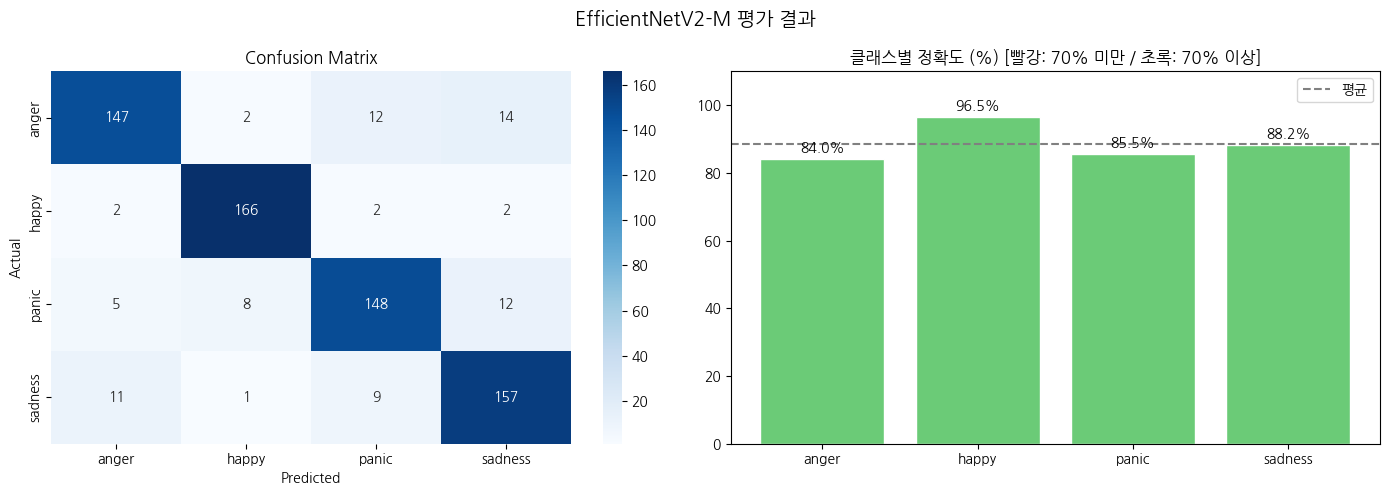

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EfficientNetV2-M 평가 결과', fontsize=14)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# 클래스별 정확도 계산 및 색상 코딩 (70% 미만: 빨간색, 이상: 초록색)
class_acc = cm.diagonal() / cm.sum(axis=1) * 100
colors = ['#FF6B6B' if a < 70 else '#6BCB77' for a in class_acc]
bars = axes[1].bar(CLASSES, class_acc, color=colors, edgecolor='white')
axes[1].bar_label(bars, fmt='%.1f%%', padding=3)
axes[1].axhline(y=sum(class_acc)/len(class_acc), color='gray', linestyle='--', label='평균')
axes[1].set_title('클래스별 정확도 (%) [빨강: 70% 미만 / 초록: 70% 이상]')
axes[1].set_ylim(0, 110)
axes[1].legend()

plt.tight_layout()
plt.savefig(str(CKPT_DIR / 'efficientnet_evaluation.png'), dpi=150)
plt.show()


## 11. 이전 모델과 성능 비교
> 각 모델 노트북을 먼저 실행해야 result.json이 생성됩니다.


=== 최종 모델 성능 비교 (전체) ===
              모델 Accuracy Top-2 Acc F1 Score ROC-AUC Cohen's Kappa      파라미터 수 학습 에폭
Swin Transformer   87.11%    96.85%   0.8718  0.9663        0.8281  86,747,324    14
   ConvNeXt-Base   88.68%       N/A   0.8861     N/A           N/A  87,570,564    16
   DeiT III-Base   86.10%    96.28%   0.8617  0.9672        0.8147  85,819,396    17
     MaxViT-Base   87.97%    95.27%   0.8790  0.9667        0.8395 118,701,784    15
       ViT-Large   85.39%    96.13%   0.8528  0.9652        0.8052 303,305,732    13
  ConvNeXt-Large   87.39%    97.42%   0.8741  0.9738        0.8319 196,236,484    14
EfficientNetV2-M   88.54%    95.99%   0.8854  0.9734        0.8472  52,863,480    32


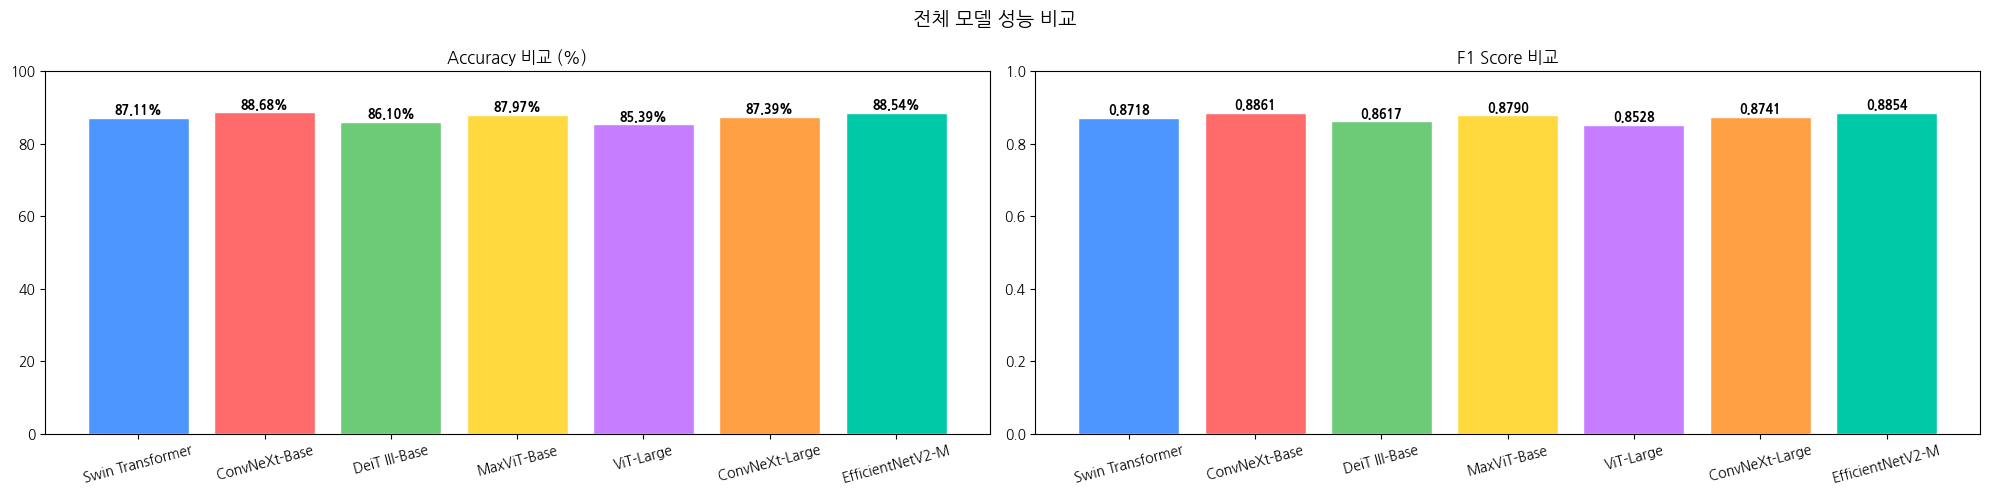

In [13]:
# 이전 모델 결과 로드 (각 노트북 실행 후 생성되는 JSON 파일)
results = {}
model_paths = {
    'EfficientNetV2-M': Path('/workspace/user3/out/checkpoints_efficientnetV2-M') / 'efficientnet_result.json',
    'Swin Transformer': Path('/workspace/user3/out/checkpoints_swin_0423_0626')             / 'swin_result.json',
    'ConvNeXt-Base'   : Path('/workspace/user3/out/checkpoints_convnext')         / 'convnext_result.json',
    'DeiT III-Base'   : Path('/workspace/user3/out/checkpoints_deit3_0423_0112')            / 'deit3_result.json',
    'MaxViT-Base'     : Path('/workspace/user3/out/checkpoints_maxvit_0423_0147')           / 'maxvit_result.json',
    'ViT-Large'       : Path('/workspace/user3/out/checkpoints_vit_large_0423_0233')        / 'vit_large_result.json',
    'ConvNeXt-Large'  : Path('/workspace/user3/out/checkpoints_convnext_large_0423_0425')   / 'convnext_large_result.json',
}

for model_name, path in model_paths.items():
    if model_name == 'EfficientNetV2-M':
        continue  # 현재 모델은 아래에서 직접 추가
    if path.exists():
        with open(path) as f:
            results[model_name] = json.load(f)
    else:
        print(f'  [{model_name}] result.json 없음. 해당 노트북을 먼저 실행하세요.')
        results[model_name] = {'accuracy': 0, 'f1_score': 0, 'params': 0, 'epochs': 'N/A'}

# EfficientNetV2-M 결과 포함
results['EfficientNetV2-M'] = {
    'accuracy'     : round(efficientnet_acc * 100, 2),
    'top2_accuracy': round(efficientnet_top2 * 100, 2),  # 이미 0~100 스케일
    'f1_score'     : round(efficientnet_f1, 4),
    'roc_auc'      : round(efficientnet_auroc, 4),
    'cohen_kappa'  : round(efficientnet_kappa, 4),
    'params'       : efficientnet_params,
    'epochs'       : len(efficientnet_history['train_loss'])
}

# 비교표 출력
comparison = pd.DataFrame({
    '모델'         : list(results.keys()),
    'Accuracy'     : [f"{v['accuracy']:.2f}%"                                         for v in results.values()],
    'Top-2 Acc'    : [f"{v['top2_accuracy']:.2f}%" if 'top2_accuracy' in v else 'N/A' for v in results.values()],
    'F1 Score'     : [f"{v['f1_score']:.4f}"                                          for v in results.values()],
    'ROC-AUC'      : [f"{v['roc_auc']:.4f}"        if 'roc_auc'       in v else 'N/A' for v in results.values()],
    "Cohen's Kappa": [f"{v['cohen_kappa']:.4f}"    if 'cohen_kappa'   in v else 'N/A' for v in results.values()],
    '파라미터 수'   : [f"{v['params']:,}"                                              for v in results.values()],
    '학습 에폭'     : [str(v.get('epochs', 'N/A'))                                      for v in results.values()],
})
print('\n=== 최종 모델 성능 비교 (전체) ===')
print(comparison.to_string(index=False))

model_names = list(results.keys())
accs   = [results[m]['accuracy'] for m in model_names]
f1s    = [results[m]['f1_score'] for m in model_names]
colors = ['#4D96FF','#FF6B6B','#6BCB77','#FFD93D','#C77DFF','#FF9F43','#00C9A7','#F368E0']

fig, axes = plt.subplots(1, 2, figsize=(20, 5))
fig.suptitle('전체 모델 성능 비교', fontsize=14)

axes[0].bar(model_names, accs, color=colors[:len(model_names)], edgecolor='white')
axes[0].set_title('Accuracy 비교 (%)'); axes[0].set_ylim(0, 100)
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(axes[0].patches, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.2f}%', ha='center', fontweight='bold', fontsize=9)

axes[1].bar(model_names, f1s, color=colors[:len(model_names)], edgecolor='white')
axes[1].set_title('F1 Score 비교'); axes[1].set_ylim(0, 1.0)
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(axes[1].patches, f1s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig(str(CKPT_DIR / 'model_comparison_all.png'), dpi=150)
plt.show()


## 12. 최종 모델 저장

In [14]:
efficientnet_result = {
    'model'        : 'EfficientNetV2-M',
    'accuracy'     : round(efficientnet_acc * 100, 2),
    'top2_accuracy': round(efficientnet_top2 * 100, 2),
    'f1_score'     : round(efficientnet_f1, 4),
    'roc_auc'      : round(efficientnet_auroc, 4),
    'cohen_kappa'  : round(efficientnet_kappa, 4),
    'params'       : efficientnet_params,
    'epochs'       : len(efficientnet_history['train_loss'])
}
with open(CKPT_DIR / 'efficientnet_result.json', 'w') as f:
    json.dump(efficientnet_result, f, indent=2)

print('=== 저장된 파일 목록 ===')
for f in sorted(CKPT_DIR.iterdir()):
    size = f.stat().st_size / 1e6
    print(f'  {f.name:<40s} {size:.1f} MB')
print('\n학습 파이프라인 완료')
print(f'\n최종 성능 요약:')
print(f'  Accuracy     : {efficientnet_acc*100:.2f}%')
print(f'  Top-2 Acc    : {efficientnet_top2*100:.2f}%')
print(f'  F1 Score     : {efficientnet_f1:.4f}')
print(f'  ROC-AUC      : {efficientnet_auroc:.4f}')
print(f"  Cohen's Kappa: {efficientnet_kappa:.4f}")
print('\n다음 단계: 앙상블 노트북에서 기존 모델과 결합')


=== 저장된 파일 목록 ===
  efficientnet_best.pth                    213.0 MB
  efficientnet_evaluation.png              0.1 MB
  efficientnet_learning_curve.png          0.1 MB
  efficientnet_result.json                 0.0 MB
  model_comparison_all.png                 0.1 MB

학습 파이프라인 완료

최종 성능 요약:
  Accuracy     : 88.54%
  Top-2 Acc    : 95.99%
  F1 Score     : 0.8854
  ROC-AUC      : 0.9734
  Cohen's Kappa: 0.8472

다음 단계: 앙상블 노트북에서 기존 모델과 결합
